In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import qmc

In [2]:
#import functions
from model_eqns_scenario_2 import malaria_model
from parameter_values_scenario import params

In [3]:
#Read data
Macapa_data_2019 = pd.read_csv('./data/Macapa_data_2019.csv')
Manaus_data_2019 = pd.read_csv('./data/Manaus_data_2019.csv')

In [4]:
Temperature_urban = Macapa_data_2019['Temp.Comp.Media']
Temperature_rural = Manaus_data_2019['Temp.Comp.Media']

Rainfall_urban = Macapa_data_2019['Precipitacao']
Rainfall_rural = Manaus_data_2019['Precipitacao']

In [5]:
initial_time = 1
final_time = len(Temperature_urban)  
tempo = np.arange(initial_time, final_time + 1)  

#Defining the initial condition Macapa

Nh_U= 5.03327e5
#Nm_U = Nh_U*params['m_U']
init_U = 306 #1500#1135 Model simulation at the end of 2018


#Defining the initial condition Manaus
Nh_R = 2.2e6 
#Nm_R = Nh_R*params['m_R']
init_R = 5000 # model simulation at the end of 2018
def create_initial_conditions(Nh_U, Nh_R, init_U, init_R, params):

    Nm_U = Nh_U * params['m_U']
    Nm_R = Nh_R * params['m_R']

    inicial = {
        'tempo': 1,
        'Sh_UU': 1 - init_U / Nh_U,
        'Sh_UR': 0,
        'Ih_UU': init_U / Nh_U,
        'Ih_UR': 0,
        'L_UU': 0,
        'L_UR': 0,
        'P_UU': 0,
        'P_UR': 0,
        'Sm_U': params['m_U'],
        'Im_U': 0,
        'Cases_U': 0,
        'Nm_U': Nm_U,
        'Nh_U': 1,

        'Sh_RR': 1 - init_R / Nh_R,
        'Sh_RU': 0,
        'Ih_RR': init_R / Nh_R,
        'Ih_RU': 0,
        'L_RR': 0,
        'L_RU': 0,
        'P_RR': 0,
        'P_RU': 0,
        'Sm_R': params['m_R'],
        'Im_R': 0,
        'Cases_R': 0,
        'Nm_R': Nm_R,
        'Nh_R': 1
    }

    df_sim = pd.DataFrame({"tempo": tempo})
    vars = ["Sh_UU", "Sh_UR", "Ih_UU", "Ih_UR", "L_UU", "L_UR", "P_UU", "P_UR", "Sm_U", "Im_U", "Cases_U", "Nm_U",  "Nh_U", 
        "Sh_RR", "Sh_RU", "Ih_RR", "Ih_RU", "L_RR", "L_RU", "P_RR", "P_RU", "Sm_R", "Im_R",  "Cases_R" , "Nm_R", "Nh_R"]
    df_sim[vars] = np.nan
    df_sim.loc[0] = inicial

    return df_sim

In [6]:
clim = {"T_u": Temperature_urban.copy(), "T_r": Temperature_rural.copy(), "R_u": Rainfall_urban.copy(), "R_r": Rainfall_rural.copy()}
m_RU1_base = 0.003  # per day baseline rural->urban outflow
m_UR1_base = 0.003  # per day baseline rural->urban outflow

tau_base = 10.0
m_RU2_base = 1.0 / tau_base
m_UR2_base = 1.0 / tau_base

m_RU1_t = np.full(final_time, m_RU1_base)
m_UR1_t = np.full(final_time, m_UR1_base)
m_RU2 = m_RU2_base
m_UR2 = m_UR2_base
mob = {"m_UR1_t": m_UR1_t, "m_UR2": m_UR2, "m_RU1_t": m_RU1_t, "m_RU2": m_RU2}
no_mob = {"m_UR1_t": 0*m_UR1_t, "m_UR2": 0*m_UR2, "m_RU1_t": 0*m_RU1_t, "m_RU2": 0*m_RU2}

In [7]:
# =========================
# PREPARE BASELINE MODEL
# =========================

def run_model(df_sim, clim, params, mob, Nh_U, Nh_R):
    sol = malaria_model(df_sim.copy(), clim, mob, params)

    Urban_cases = (sol['Cases_U'] * Nh_U).cumsum().iloc[-1]
    Rural_cases = (sol['Cases_R'] * Nh_R).cumsum().iloc[-1]

    return Urban_cases, Rural_cases


# ---- No mobility baseline ----
no_mob = {
    "m_UR1_t": np.zeros(final_time),
    "m_UR2": 0.0,
    "m_RU1_t": np.zeros(final_time),
    "m_RU2": 0.0
}

In [8]:
df_sim = create_initial_conditions( Nh_U, Nh_R, init_U, init_R, params)
Urban_base, Rural_base = run_model(df_sim, clim, params, no_mob, Nh_U, Nh_R) 

print("Baseline (no mobility):", Urban_base, Rural_base)

Baseline (no mobility): 3553.9368218029895 64911.0303713819


In [9]:
# =========================
# PART 1: PRCC ANALYSIS
# =========================

# Parameter ranges
param_ranges = {
    "m_UR1": [0.0012, 0.0048], # baseline value is 0.003
    "m_UR2": [1/25, 1/6],    # baseline value is 1/10
    "m_RU1": [0.0012, 0.0048], # baseline value is 0.003
    "m_RU2": [1/25, 1/6],    # baseline value is 1/10
    "Nh_U": [375000, 625000],      # baseline value is 500000
    "Nh_R": [1.5e6, 250000]     # baseline value is 2000000
}

n_samples = 300
keys = list(param_ranges.keys())

# Latin Hypercube Sampling using scipy
sampler = qmc.LatinHypercube(d=len(keys))
lhs_samples = sampler.random(n=n_samples)

param_values = []
outputs_U = []
outputs_R = []

print("Running PRCC simulations...")

for i in range(n_samples):
    sample = {}

    for j, key in enumerate(keys):
        low, high = param_ranges[key]
        sample[key] = low + (high - low) * lhs_samples[i, j]

    param_values.append(sample)

    # Use sampled populations here
    Nh_U_temp = sample["Nh_U"]
    Nh_R_temp = sample["Nh_R"]

    mob = {
        "m_UR1_t": np.full(final_time, sample["m_UR1"]),
        "m_UR2": sample["m_UR2"],
        "m_RU1_t": np.full(final_time, sample["m_RU1"]),
        "m_RU2": sample["m_RU2"]
    }
    
    df_sim_temp = create_initial_conditions( Nh_U_temp, Nh_R_temp, init_U, init_R, params)
    
    U_cases, R_cases = run_model(df_sim_temp, clim, params, mob, Nh_U_temp, Nh_R_temp)

    outputs_U.append((U_cases - Urban_base) / Urban_base)
    outputs_R.append((R_cases - Rural_base) / Rural_base)


# Convert to DataFrame
df_params = pd.DataFrame(param_values)
df_outputs = pd.DataFrame({
    "Urban": outputs_U,
    "Rural": outputs_R
})

df_all = pd.concat([df_params, df_outputs], axis=1)

# Compute PRCC (Spearman approximation)
prcc_urban = df_all.corr(method='spearman')['Urban'][:-2]
prcc_rural = df_all.corr(method='spearman')['Rural'][:-2]

print("\nPRCC Urban:\n", prcc_urban)
print("\nPRCC Rural:\n", prcc_rural)




Running PRCC simulations...

PRCC Urban:
 m_UR1    0.267241
m_UR2   -0.305266
m_RU1    0.166135
m_RU2   -0.244931
Nh_U     0.291706
Nh_R    -0.800931
Name: Urban, dtype: float64

PRCC Rural:
 m_UR1   -0.594803
m_UR2    0.615229
m_RU1    0.110425
m_RU2   -0.119465
Nh_U    -0.128723
Nh_R     0.360546
Name: Rural, dtype: float64


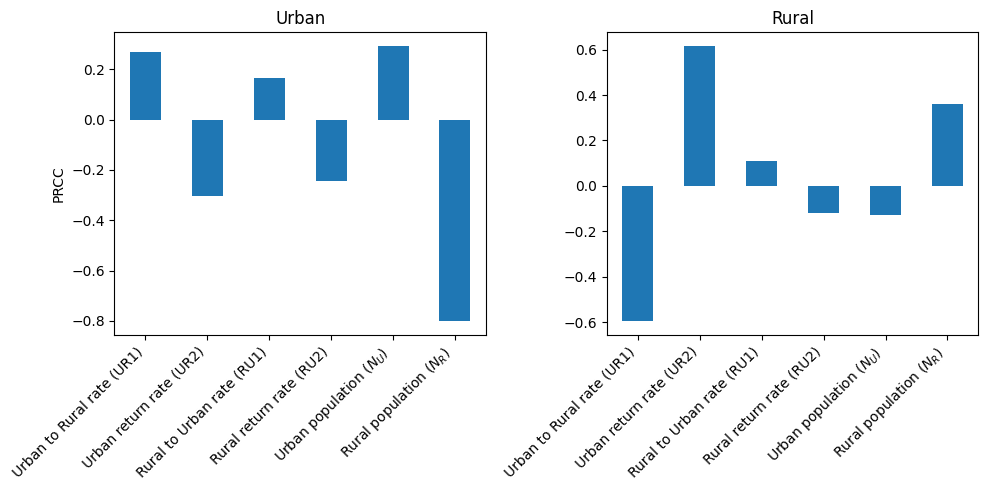

In [10]:
# ---- Plot PRCC ----
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Define descriptive labels
param_labels = [
    "Urban to Rural rate (UR1)", 
    "Urban return rate (UR2)", 
    "Rural to Urban rate (RU1)", 
    "Rural return rate (RU2)", 
    "Urban population ($N_U$)", 
    "Rural population ($N_R$)"
]

# Urban PRCC
prcc_urban.plot(kind='bar', ax=ax[0])
ax[0].set_title("Urban")
ax[0].set_ylabel("PRCC")
ax[0].set_xticklabels(param_labels, rotation=45, ha='right')

# Rural PRCC
prcc_rural.plot(kind='bar', ax=ax[1])
ax[1].set_title("Rural")
ax[1].set_xticklabels(param_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Fig_PRCC.pdf", dpi = 300, bbox_inches='tight')
plt.show()

In [11]:
# =========================
# PART 2: CONTOUR ANALYSIS
# =========================

scale = np.linspace(0, 2, 25)
M1, M2 = np.meshgrid(scale, scale)

def contour_pair(m1_base, m2_base, vary="UR"):

    Z_U = np.zeros_like(M1)
    Z_R = np.zeros_like(M1)

    for i in range(len(scale)):
        for j in range(len(scale)):

            if vary == "UR":
                m_UR1 = m1_base * scale[i]
                m_UR2 = m2_base * scale[j]
                m_RU1 = m_RU1_base
                m_RU2 = m_RU2_base

            elif vary == "RU":
                m_RU1 = m1_base * scale[i]
                m_RU2 = m2_base * scale[j]
                m_UR1 = m_UR1_base
                m_UR2 = m_UR2_base

            elif vary == "SYM":
                m_UR1 = m_UR1_base * scale[i]
                m_RU1 = m_RU1_base * scale[i]
                m_UR2 = m_UR2_base * scale[j]
                m_RU2 = m_RU2_base * scale[j]

            mob = {
                "m_UR1_t": np.full(final_time, m_UR1),
                "m_UR2": m_UR2,
                "m_RU1_t": np.full(final_time, m_RU1),
                "m_RU2": m_RU2
            }

            U_cases, R_cases = run_model(df_sim, clim, params, mob, Nh_U, Nh_R)

            Z_U[i, j] = (U_cases - Urban_base) / Urban_base
            Z_R[i, j] = (R_cases - Rural_base) / Rural_base

    return Z_U, Z_R


print("Running contour simulations...")

Z1_U, Z1_R = contour_pair(m_UR1_base, m_UR2_base, "UR")
Z2_U, Z2_R = contour_pair(m_RU1_base, m_RU2_base, "RU")
Z3_U, Z3_R = contour_pair(m_UR1_base, m_UR2_base, "SYM")




Running contour simulations...


/var/folders/d0/77rznsnx6_gd_t700fcv_3cc0000gn/T/ipykernel_7057/3272318260.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


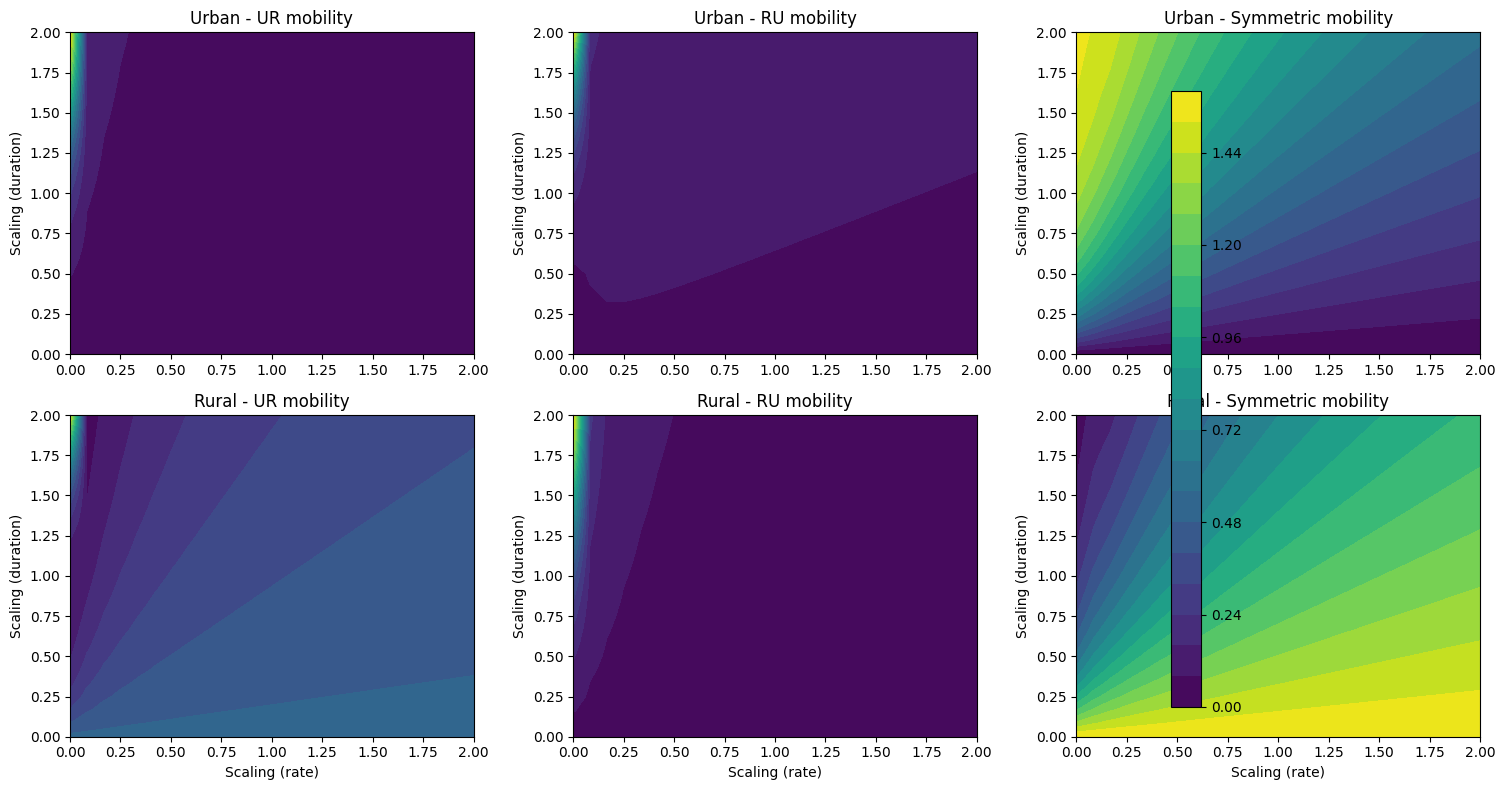

In [12]:
# =========================
# PLOT 2x3 CONTOUR
# =========================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

titles = ["UR mobility", "RU mobility", "Symmetric mobility"]

for col, (ZU, ZR) in enumerate([(Z1_U, Z1_R), (Z2_U, Z2_R), (Z3_U, Z3_R)]):

    cs1 = axes[0, col].contourf(M1, M2, ZU, levels=20)
    axes[0, col].set_title(f"Urban - {titles[col]}")

    cs2 = axes[1, col].contourf(M1, M2, ZR, levels=20)
    axes[1, col].set_title(f"Rural - {titles[col]}")

    axes[1, col].set_xlabel("Scaling (rate)")
    axes[0, col].set_ylabel("Scaling (duration)")
    axes[1, col].set_ylabel("Scaling (duration)")

fig.colorbar(cs1, ax=axes[:, :], orientation='vertical')

plt.tight_layout()
plt.show()

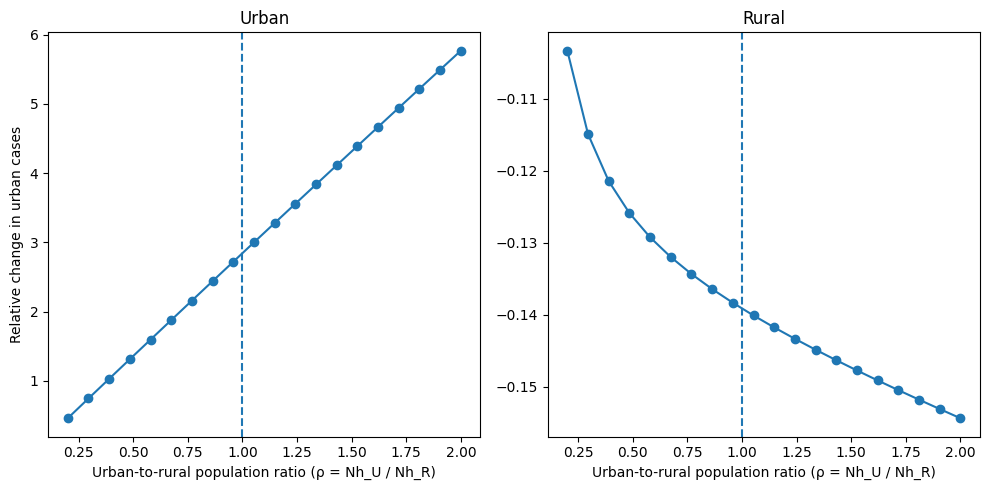

In [13]:
rho_vals = np.linspace(0.2, 2.0, 20)

Z1 = []
Z2 = []
N_total = Nh_U + Nh_R

for rho in rho_vals:

    Nh_U_temp = (rho / (1 + rho)) * N_total
    Nh_R_temp = N_total - Nh_U_temp

    df_sim = create_initial_conditions(
        Nh_U_temp, Nh_R_temp, init_U, init_R, params
    )

    mob = {
        "m_UR1_t": np.full(final_time, m_UR1_base),
        "m_UR2": m_UR2_base,
        "m_RU1_t": np.full(final_time, m_RU1_base),
        "m_RU2": m_RU2_base
    }

    U_cases, R_cases = run_model(
        df_sim, clim, params, mob,
        Nh_U_temp, Nh_R_temp
    )

    Z1.append((U_cases - Urban_base) / Urban_base)
    Z2.append((R_cases - Rural_base) / Rural_base)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(rho_vals, Z1, marker='o')
axs[1].plot(rho_vals, Z2, marker='o')

axs[0].set_xlabel("Urban-to-rural population ratio (ρ = Nh_U / Nh_R)")
axs[1].set_xlabel("Urban-to-rural population ratio (ρ = Nh_U / Nh_R)")
axs[0].set_ylabel("Relative change in urban cases")
axs[0].set_title("Urban")
axs[1].set_title("Rural")

axs[0].axvline(1, linestyle='--')  # where urban = rural
axs[1].axvline(1, linestyle='--')  # where urban = rural
plt.tight_layout()
plt.show()

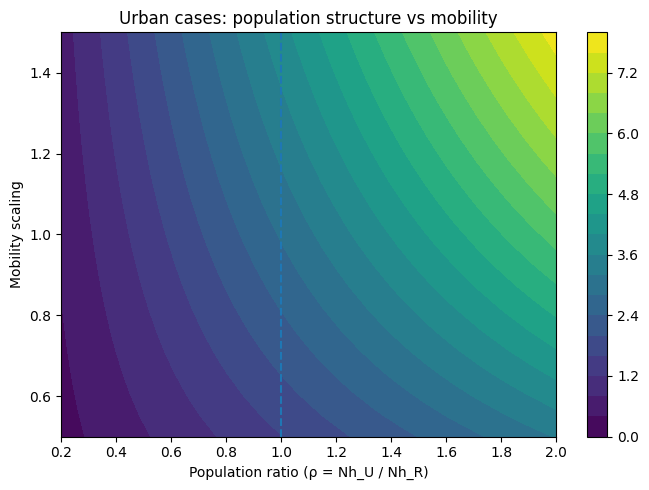

In [14]:
rho_vals = np.linspace(0.2, 2.0, 20)
mob_scale = np.linspace(0.5, 1.5, 20)

RHO, MOB = np.meshgrid(rho_vals, mob_scale)

Z = np.zeros_like(RHO)

N_total = Nh_U + Nh_R

for i in range(len(mob_scale)):
    for j in range(len(rho_vals)):

        rho = RHO[i, j]
        scale = MOB[i, j]

        Nh_U_temp = (rho / (1 + rho)) * N_total
        Nh_R_temp = N_total - Nh_U_temp

        df_sim = create_initial_conditions(
            Nh_U_temp, Nh_R_temp, init_U, init_R, params
        )

        mob = {
            "m_UR1_t": np.full(final_time, m_UR1_base * scale),
            "m_UR2": m_UR2_base,
            "m_RU1_t": np.full(final_time, m_RU1_base * scale),
            "m_RU2": m_RU2_base
        }

        U_cases, _ = run_model(
            df_sim, clim, params, mob,
            Nh_U_temp, Nh_R_temp
        )

        Z[i, j] = (U_cases - Urban_base) / Urban_base


# Plot
plt.figure(figsize=(7,5))
cp = plt.contourf(RHO, MOB, Z, levels=20)
plt.colorbar(cp)

plt.xlabel("Population ratio (ρ = Nh_U / Nh_R)")
plt.ylabel("Mobility scaling")
plt.title("Urban cases: population structure vs mobility")

plt.axvline(1, linestyle='--')  # urban = rural

plt.tight_layout()
plt.show()